<a href="https://colab.research.google.com/github/muhammed-sajid/CodeAlpha_UnemploymentAnalysis/blob/main/Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CodeAlpha
Tasl2 : Unemployment Analysis with Python

Dataset from kaggle :https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Unemployment in India.csv')
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleaning

In [33]:
data.columns = data.columns.str.strip()

data['Date'] = pd.to_datetime(data['Date'])

print(data.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


/tmp/ipykernel_1143/903784819.py:3: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])


In [34]:
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaT,NaN,NaN,NaN,NaN,NaN
764,NaN,NaT,NaN,NaN,NaN,NaN,NaN
765,NaN,NaT,NaN,NaN,NaN,NaN,NaN
766,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [35]:
data.dropna(inplace=True)

In [36]:
data.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [37]:
#Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [38]:
print(data.duplicated().sum())

0


Exploratory Data Anlaysis(EDA)

In [39]:
#Statistical summary
data.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


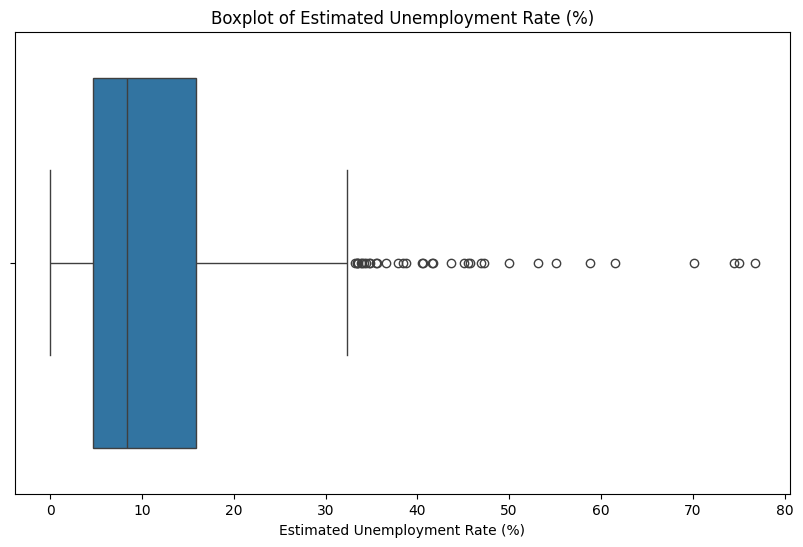

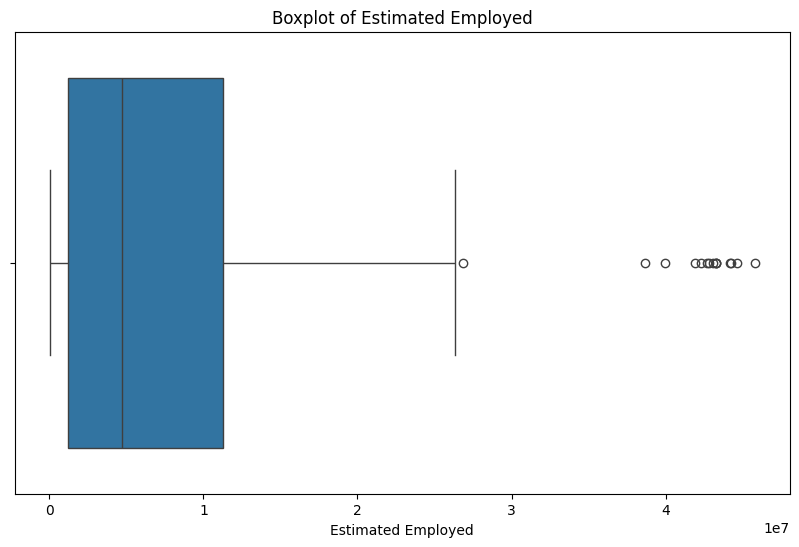

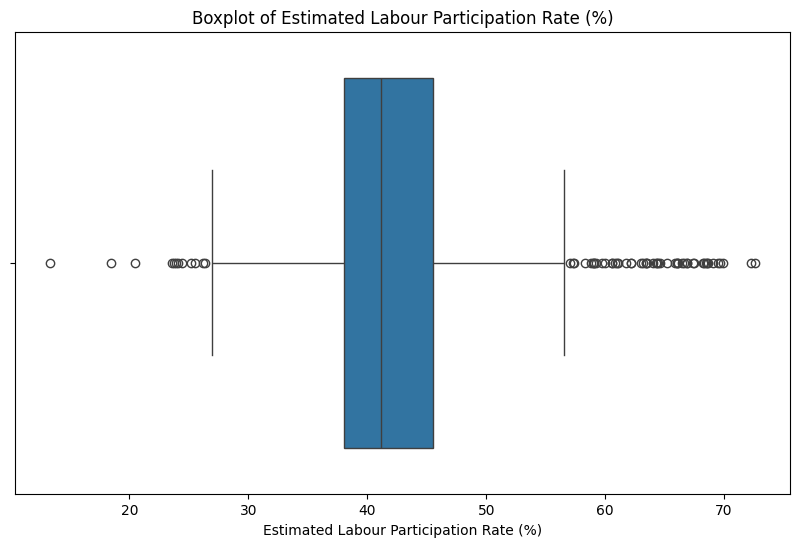

In [40]:
numeric_column = data.select_dtypes(include=[np.number]).columns.to_list()

for col in numeric_column:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=data[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

I checked for outliers,but i did not remove them because they represent real unemployed data during Covid-19.Since the goal of this project is to analyze  unemployment trends and the impact of pandamic, those extreme values are import information rather than error.

Unemployment Trends Over Time

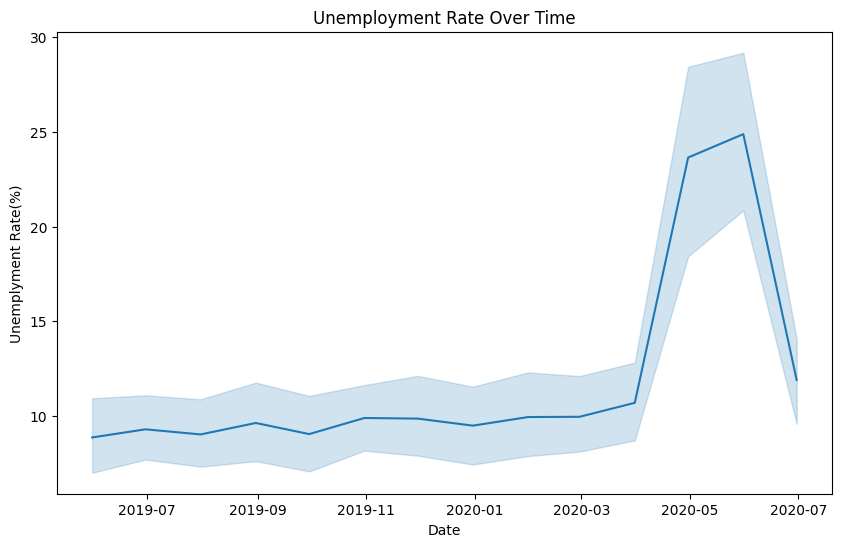

In [41]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=data,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemplyment Rate(%)')
plt.show()

Covid-19 Impact Analysis

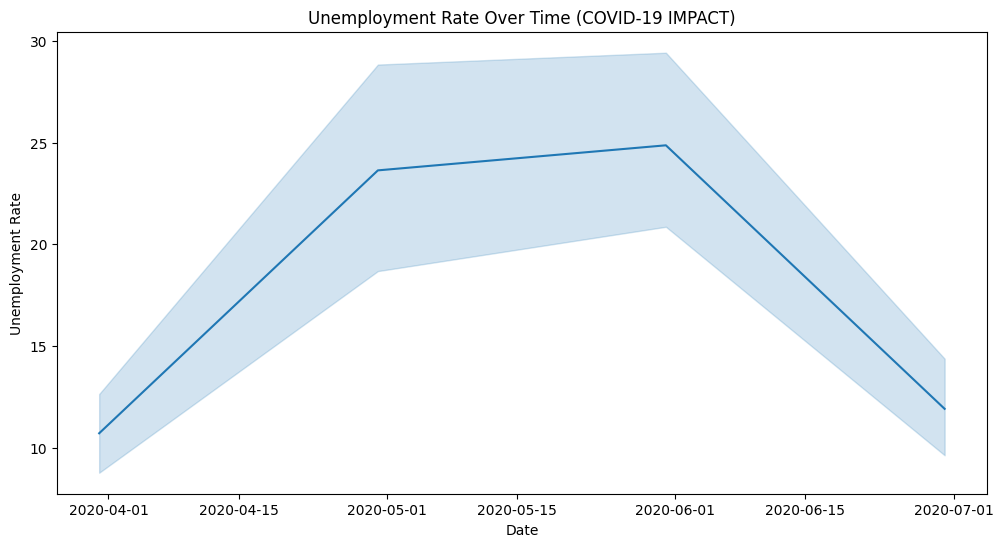

In [45]:
covid_data = data[data['Date'] >= '2020-03-01']

plt.figure(figsize=(12,6))
sns.lineplot(
    data=covid_data,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)
plt.title('Unemployment Rate Over Time (COVID-19 IMPACT)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.show()

"Before the Covid-19 pandemic, the average unemployment rate was relatively stable at around 9–10%. However, during the peak Covid-19 lockdown period in 2020, the unemployment rate increased dramatically, reaching approximately 24–25%. This represents a significant rise in unemployment due to the economic disruptions caused by the pandemic."

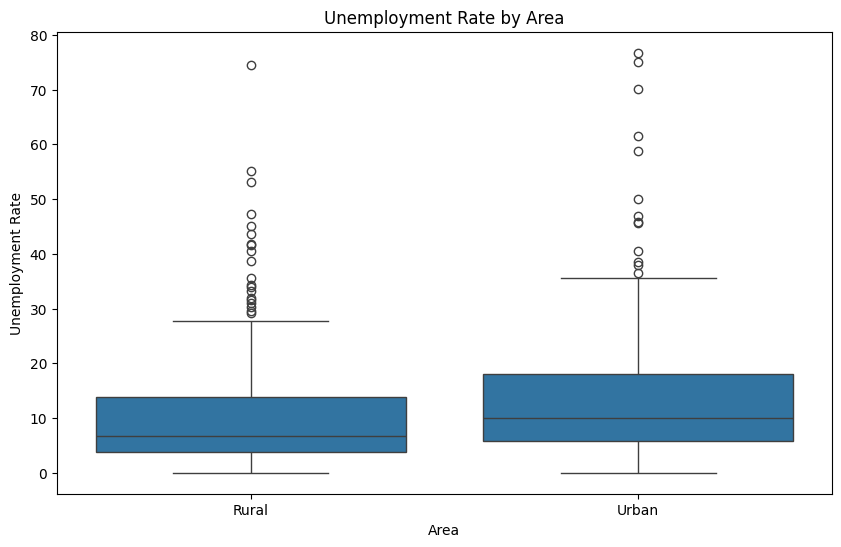

In [47]:
#Area Analysis (Urban vs Rural)
plt.figure(figsize=(10,6))
sns.boxplot(
    data= data,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)
plt.title('Unemployment Rate by Area')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate')
plt.show()

Urban areas experienced higher unemployment rates than rural areas, with greater variation and more extreme values. This suggests that urban regions were more affected by economic disruptions, particularly during the Covid-19 pandemic.

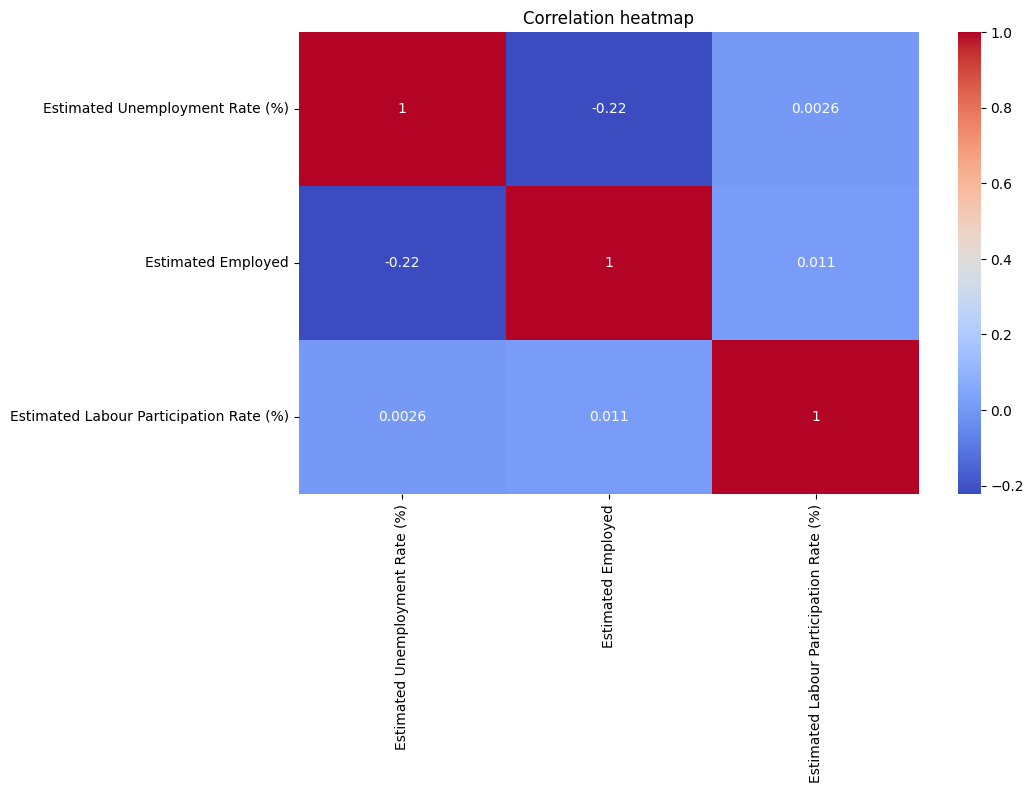

In [51]:
#Heatmap
numeric_column = data.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_column.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

Seasonal Trend Anlaysis in month

The correlation heatmap indicates weak relationships among the variables. Unemployment rate has a slight negative correlation with employment (-0.22), while labour participation rate shows almost no correlation with either unemployment or employment. Overall, no strong linear relationships are observed in the dataset.

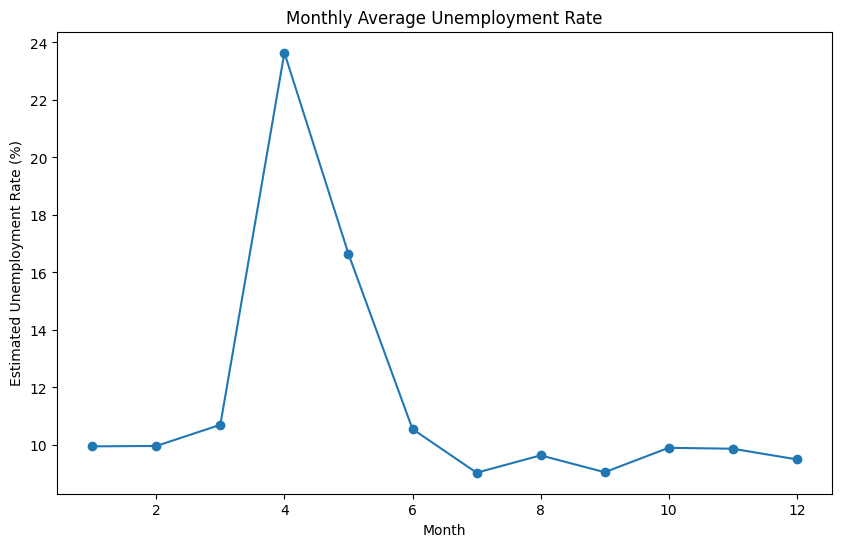

In [54]:
data['Month'] = data['Date'].dt.month
monthly_unemployment = data.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_unemployment.plot(
    kind='line',
    marker ='o',
    figsize= (10,6)
)
plt.title('Monthly Average Unemployment Rate')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.xlabel('Month')
plt.show()

The monthly unemployment trend shows a sharp increase in April and May 2020, with April recording the highest unemployment rate of approximately 24%. This spike coincides with the Covid-19 lockdown period, highlighting its significant impact on employment. After May, unemployment gradually declined and returned close to pre-pandemic levels. No clear seasonal pattern is observed, as the Covid-19 disruption was the dominant factor affecting unemployment trends.



*   The unemployment rate remained relatively stable before the Covid-19 pandemic, averaging around 9–10% across most regions.
*   A sharp increase in unemployment was observed during April and May 2020, with April recording the highest average unemployment rate of approximately 24%. This surge was primarily caused by the Covid-19 lockdown and economic restrictions.
*   After the peak lockdown period, unemployment gradually declined and moved closer to pre-pandemic levels, indicating a partial recovery of economic activities and employment opportunities.
*   Urban areas experienced higher unemployment rates than rural areas, with greater variability and more extreme unemployment values. This suggests that urban economies were more severely affected by the pandemic.
*   Outliers were identified but retained in the analysis, as they represent genuine economic disruptions during the Covid-19 period rather than data errors.
*  The correlation analysis revealed weak relationships among unemployment rate, employment estimates, and labour participation rate, indicating that unemployment is influenced by multiple economic and social factors.
*  No strong seasonal pattern was observed in the dataset. The most significant trend was the temporary spike in unemployment during the Covid-19 lockdown period.

